# Pregunta 1. Pregunta de desarrollo

(2 pts). Escenario:

Suponga que una plataforma de análisis de opiniones recoge las valoraciones de productos tacnológicos realizadas por usuarios de distintos países. Se desea estimar la probanilidad de que un usuario de México y uno de Argentina otorguen la misma calificación (en una escala de 1 a 5) al mismo producto tecnológico tras una reseña en vídeo publicada por la marca.

A partir de este escenario, complete las siguientes cuestiones:
1. Discusión sobre la elección de la fórmula estadística utilizada para calcular la probabilidad de coincidencia de calificación entre ambos usuarios.
2. Cálculo numérico de dicha probabilidad a partir de una muestra de datos simulada.

Representa la solución en un script de R

### 1. Justificación de la fórmula

Podemos asumor que la probabilidad de que un usuario mexicano otorge una de cinco estrellas a un producto es independiente que otro usuario, esta vez argentino, haga lo mismo. De esta forma, identificamos el problema como una intersección (los resultados deben coincidir) de dos probabilidades independientes entre sí.

Si $P(B\mid A) = P(B)$ por no verse afectado por el hecho de que haya ocurrido A, entonces

$$P(B) = \frac{P(A \cap B)}{P(A)} \leftrightarrow P(A \cap B) = P(A) \times P(B)$$

Luego si dos sucesos son independientes entonces $P(A \cap B) = P(A) \times P(B)$

### 2. Cálculo numérico apartir de muestra simulada
Para este ejemplo práctico de la fórmula anterior voy a utilizar datos generados de forma aleatoria.

In [1]:
set.seed(123)

# Distribución de probabilidad de calificación
prob_mexico <- c(0.10, 0.15, 0.25, 0.30, 0.20)
prob_argentina <- c(0.05, 0.20, 0.30, 0.25, 0.20)

# -- OPCION 1 -- Cálculo teórico
# P(X=Y) = sum_k P(X=k)*P(Y=k)  (independencia entre usuarios)
p_teorica <- sum(prob_mexico * prob_argentina)
cat("Probabilidad teórica de coincidencia:", round(p_teorica, 4), "\n")

# -- OPCION 2 -- Simulacion Monte Carlo
n <- 10000
ratings_mexico <- sample(1:5, n, replace = TRUE, prob = prob_mexico)
ratings_argentina <- sample(1:5, n, replace = TRUE, prob = prob_argentina)

p_simulada <- mean(ratings_mexico == ratings_argentina)
cat("Probabilidad simulada (n=10000) es:", round(p_simulada, 4), "\n")

Probabilidad teórica de coincidencia: 0.225 
Probabilidad simulada (n=10000) es: 0.2253 


# Pregunta 2. Pregunta de desarrollo.

(3 pts) Escenario:

Una plataforma de e-learning ha implementado un nuevo sistema de tutoría inteligente para estudiantes de educación secundaria en América Latina. Se desea cconocer el impacto de esta tutoría en el rendimiento académico de los estudiantes de Ecuador en las asignaturas STEM (Ciencia, Tecnología, Ingeniería y Matemñaticas).

A partir de aquí, completa el escenario planteado para poder responder a las siguientes cuestiones:
1. Enuncia un problema de Análisis de Datos que se podría estudiar en este contexto.
2. Propón un algorimto o enfoque de análisis para resolver el problema que hayas propuesto.

Representa la solución en un script de R

### 1. Problema propuesto

¿La implementación del sistema de tutoría inteligente produce una mejora estadísticamente significativa en el rendimiento académico (calificación media en asignaturas STEM) de los estudiantes de secundaria de Ecuador, en comparación con su rendimiento previo a la implementación (o frente a un grupo de control sin tutoría)?

Se trata de un problema de INFERENCIA DE COMPARACIÓN DE MEDIAS entre dos condiciones (antes/después del mismo grupo de estudiantes o grupo tratamiento vs. grupo de control)

### 2. Enfoque de aánlisis propuesto

Dado que se comparan las notas de los mismos estudiantes antes y después de usar el tutor inteligente, el diseño es de muestras pareadas (dependientes), por lo que el test adecuado es un t-test pareado (paired t-test).

Hipótesis:

H0 mu = 0

H1 mu <> 0

La media mu será cero cuando no haya diferencia entre la media de antes y después de que se introdujese el sistema inteligente.


	Paired t-test

data:  nota_post and nota_pre
t = 5.8117, df = 39, p-value = 4.729e-07
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 0.5627463       Inf
sample estimates:
mean of the differences 
                 0.7925 



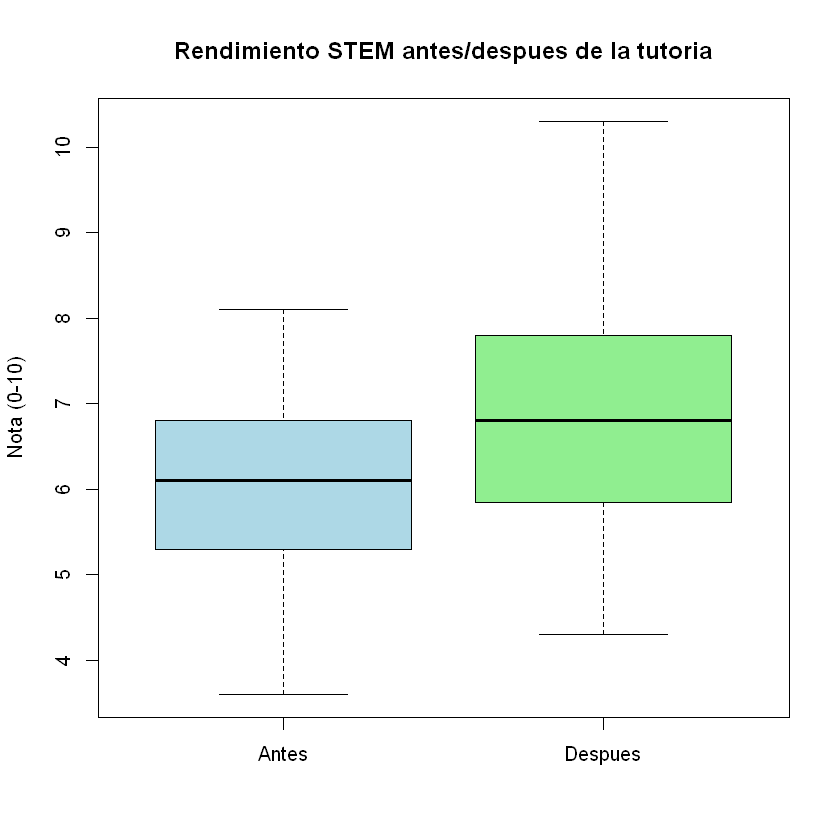

In [3]:
set.seed(123)

# -- SIMULACIÓN -- de las notas obtenidas
n <- 40
nota_pre  <- round(rnorm(n, mean = 6.0, sd = 1.2), 1)
nota_post <- round((nota_pre + rnorm(n, mean = 0.8, sd = 0.9)), 1)

# -- TEST T --
resultado <- t.test(nota_post, nota_pre, paired = TRUE, alternative = "greater")
print(resultado)

# -- VISUALIZACIÓN --
boxplot(nota_pre, nota_post,
    names = c("Antes", "Despues"),
    main = "Rendimiento STEM antes/despues de la tutoria",
    ylab = "Nota (0-10)", col = c("lightblue", "lightgreen"))

El p-value resultante es mucho menor que 0.05 por lo que rechazamos la hipótesis nula. Por lo tanto podemos afirmar con seguridad que el sistema de tutor inteligente sí afecta directamente al desempeño de los estudiantes y, como se puede ver en la gráfica anterior, mejora considerablemente sus calificaciones.

# Pregunta 3. Pregunta de desarrollo.

(5 pts) Diseña un estudio estadístico que permita analizar el consumo de proteínas en niños pequeños, comparando la situación en dos escenarios diferentes: Latinoamérica y Europa. En tu respuesta indica claramente:
1. La definición de un problema estadístico que te permita ahondar en la cuestión aportada.
2. ¿Qué datos recogerías y cómo lo harías?
3. ¿Como escribirías numéricamente los datos? Menciona que cantidades calcularías y qué podrías aprender de estos cálculos.
4. ¿Cómo representas gráficamente los datos? ¿Qué información podrías transmitir con estas representaciones gráficas?

Representa la solución en un script de R

### a) Definición del problema

¿Existen diferencias significativas en el consumo diario de proteínas (g/día) en niños pequeños (2-5 años) entre Latinoamérica y Europa, y en qué medida ese consumo se ajusta a las recomendaciones nutricionales (ej. OMS: ~13-19 g/día según edad)?

Es un problema de comparación de dos poblaciones independientes (dos regiones geográficas), combinando:

- Estadística descriptiva (caracterizar cada región).
- Inferencia estadística (contraste de hipótesis sobre la diferencia de medias).

$$
Hipótesis \\
H_0 : \mu _{LatAm} = \mu _{Europa} \\
H_1 : \mu _{LatAm} \ne \mu _{Europa}
$$

### b) Recogida de datos

Para este estudio necesitamos saber:
1. *La variable objetivo:* Representa el consumo de proteínas como gramos consumidos por día.
2. *Las vasriables de control:* Aquí se juntan variables que nos puedan ser útiles para clasificar a los individuos de la población, como pueden ser la edad, el sexo o el país de origen.

Los datos se recogerán de forma observacional mediante encuestas, ya que no se manipula el consumo de proteína tansolo analizamos (observamos) la población ya existente. Las encuestas obtendrán una muestra aleatoria por región (país) que sea, idealmente, los bastante grande como para aplicar el TCL ($n \ge 30$).

In [4]:
# -- SIMULACIÓN DE ENCUESTAS  --
set.seed(123)

n <- 50
proteina_latam  <- round(rnorm(n, mean = 14.5, sd = 3.2), 1)
proteina_europa <- round(rnorm(n, mean = 17.0, sd = 2.8), 1)

umbral_oms <- 13 # g/dia, umbral minimo recomendado (ficticio)

### C. Análisis de los datos

Para cada región calculamos:
- **Media y Mediana,** tendencia central del consumo de proteína.
- **Desviación Estándar y Rango Intercuartílico (IQR):** variabilidad y dispersión.
- **Mínimo y Máximo,** para detectar los casos extremos (outliers).
- **Proporción de niños por debajo del umbral recomendado.** Riesgo nutricional.
- **Diferencia de medias e intervalo de confianza al 95%.** Precisión de la diferencia entre regiones.
- **p-valor del test t.** Significancia estadística de la diferencia.

In [5]:
# -- ESTADÍSTICA DESCRIPTIVA --
resumen <- function(x) c(
    media = mean(x), mediana = median(x),
    sd = sd(x), IQR = IQR(x),
    min = min(x), max = max(x)
)

cat("Resumen LatAm:\n");  print(resumen(proteina_latam))
cat("\nResumen Europa:\n"); print(resumen(proteina_europa))

prop_bajo_latam  <- mean(proteina_latam < umbral_oms)
prop_bajo_europa <- mean(proteina_europa < umbral_oms)
cat("\n% ninios bajo umbral OMS - LatAm:", round(prop_bajo_latam*100, 1), "%\n")
cat("% ninios bajo umbral OMS - Europa:", round(prop_bajo_europa*100, 1), "%\n")

Resumen LatAm:
   media  mediana       sd      IQR      min      max 
14.61600 14.25000  2.95803  4.00000  8.20000 21.40000 

Resumen Europa:
    media   mediana        sd       IQR       min       max 
17.404000 17.400000  2.533124  2.725000 10.500000 23.100000 

% ninios bajo umbral OMS - LatAm: 28 %
% ninios bajo umbral OMS - Europa: 4 %


In [6]:
# -- TEST T --
tres <- t.test(proteina_latam, proteina_europa)
print(tres)


	Welch Two Sample t-test

data:  proteina_latam and proteina_europa
t = -5.0621, df = 95.734, p-value = 2.005e-06
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -3.881283 -1.694717
sample estimates:
mean of x mean of y 
   14.616    17.404 



En este ejemplo como p-value es muy inferior a 0.05 rechazamos la hipótesis nula, por lo tanto hay una clara diferencia entre el consumo de proteínas en los niños de Latino América y los de Europa.

### D. Representación gráfica

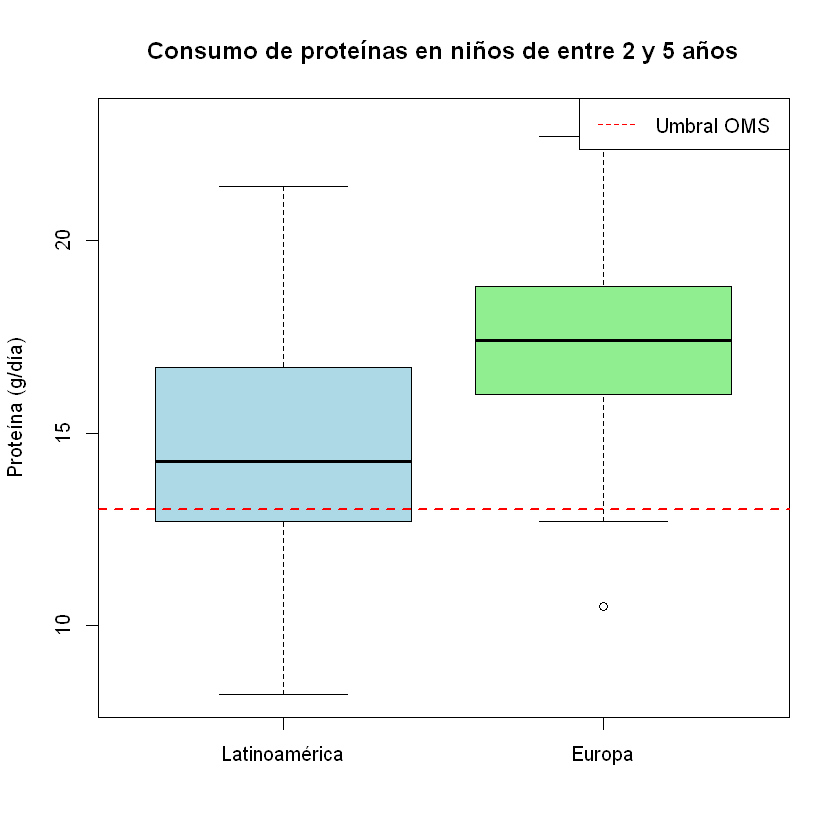

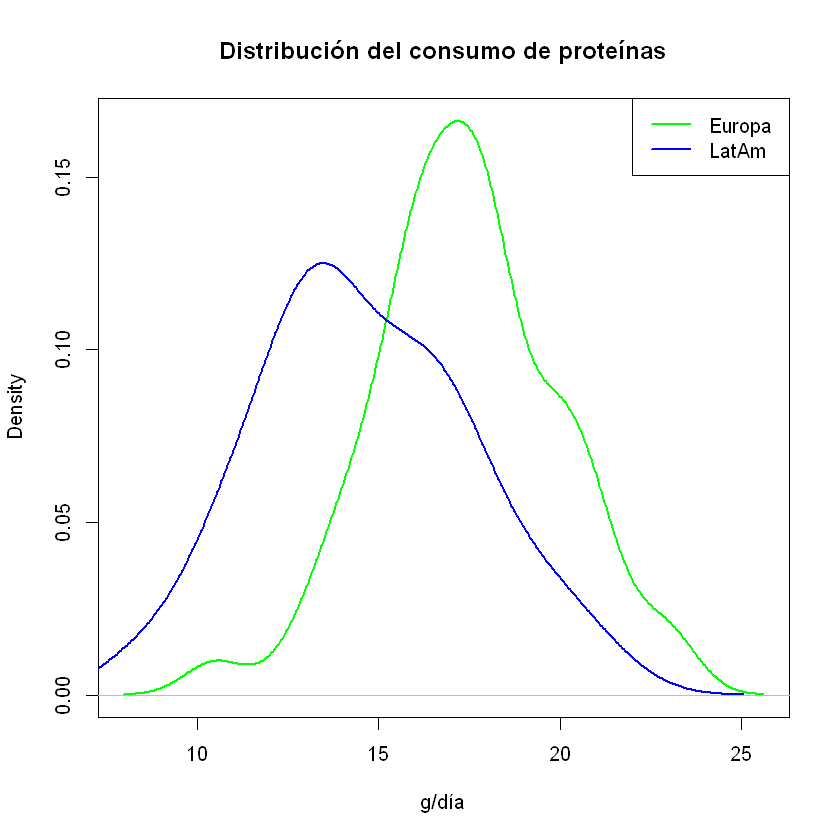

In [7]:
# -- REPRESENTACIÓN GRÁFICA --
boxplot(proteina_latam, proteina_europa,
    names = c("Latinoamérica", "Europa"),
    main = "Consumo de proteínas en niños de entre 2 y 5 años",
    ylab = "Proteína (g/día)", col = c("lightblue", "lightgreen"))
abline(h = umbral_oms, col = "red", lty = 2, lwd = 2)
legend("topright", legend = "Umbral OMS", col = "red", lty = 2)

# densidades superpuestas
plot(density(proteina_europa), col = "green", lwd = 2,
    main = "Distribución del consumo de proteínas", xlab = "g/día")
lines(density(proteina_latam), col = "blue", lwd = 2)
legend("topright", legend = c("Europa", "LatAm"), col = c("green", "blue"), lwd = 2)